Choosing from all possible events


X shape: (576, 22, 1001)
y shape: (576,)
Computing rank from data with rank=None
    Using tolerance 67 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=feet covariance using LEDOIT_WOLF
Done.
Estimating class=left_hand covariance using LEDOIT_WOLF
Done.
Estimating class=right_hand covariance using LEDOIT_WOLF
Done.
Estimating class=tongue covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 67 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=feet covariance using LEDOIT_WOLF
Done.
Estimating class=left_hand covariance using LEDOIT_WOLF
Done.
Estimating class=right_hand covariance using LEDOIT_WOLF
Done.
Estimating class=tongue covariance using LED

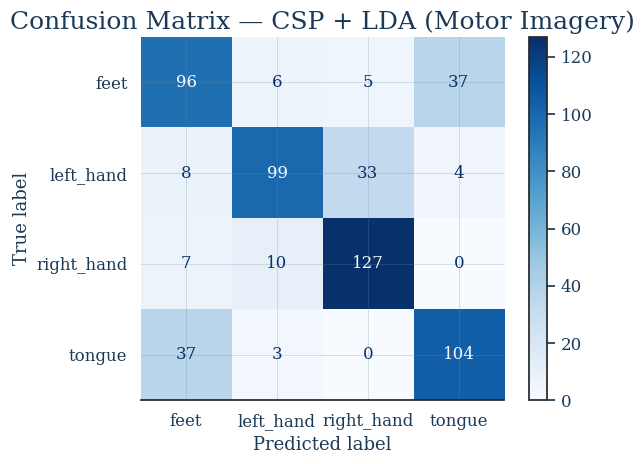

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score,
                              confusion_matrix, ConfusionMatrixDisplay)
from mne.decoding import CSP
from moabb.datasets import BNCI2014_001
from moabb.paradigms import MotorImagery

# ─────────────────────────────────────────────────────────────────────────────
# ITR (Information Transfer Rate) Computation
# Quantifies BCI throughput in bits/min using Wolpaw's formula.
# Returns 0 when accuracy is at or below chance level (p ≤ 1/N),
# since the channel carries no usable information in that regime.
# ─────────────────────────────────────────────────────────────────────────────
def compute_itr(n_classes, accuracy, trial_duration_sec):
    p, N = accuracy, n_classes
    if p <= 1 / N:
        return 0.0
    B = p * np.log2(p) + (1 - p) * np.log2((1 - p) / (N - 1)) + np.log2(N)
    return B * (60 / trial_duration_sec)


    
# --- Data ---
dataset = BNCI2014_001()
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=32)
X, y, _ = paradigm.get_data(dataset, subjects=[1])
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

# --- Pipeline: CSP + LDA ---
pipeline = Pipeline([
    ('csp', CSP(n_components=4, reg='ledoit_wolf', log=True)),
    ('lda', LDA(solver='lsqr', shrinkage='auto'))
])

# --- Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipeline, X, y, cv=cv)

# --- Metrics ---
acc   = accuracy_score(y, y_pred)
kappa = cohen_kappa_score(y, y_pred)
prec  = precision_score(y, y_pred, average='macro')
reca  = recall_score(y, y_pred, average='macro')
f1    = f1_score(y, y_pred, average='macro')
itr   = compute_itr(n_classes=4, accuracy=acc, trial_duration_sec=4.0)

print(f"Accuracy  : {acc:.4f}")
print(f"Kappa     : {kappa:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {reca:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ITR       : {itr:.2f} bits/min")

# --- Confusion Matrix ---
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — CSP + LDA (Motor Imagery)")
plt.tight_layout()
plt.show()